### MNIST classifier using alternating projections (batched)

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib
matplotlib.use('Agg')

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.getcwd()))

import jax.numpy as jnp
import jax.random as random
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import optax

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

rand_key = random.key(42)

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/scratch/brussel/vo/000/bvo00004/vsc38352/learning_with_projections/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/scratch/brussel/vo/000/bvo00004/vsc38352/learning_with_projections/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/scratch/brussel/vo/000/bvo00004/vsc38352/learning_with_projections/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
An NVIDIA GPU may be present on this machine, but a CUDA-en

In [2]:
@jax.jit
def leakyReluActivationVectorized(x, W, z, slope=0.1):
    H = W @ x
    x_1 = jnp.clip((H + slope * z) / (1.0 + slope * slope), a_max=0)
    y_1 = slope * x_1
    dist_1 = (H - x_1)**2 + (z - y_1)**2
    x_2 = jnp.clip((H + z) / 2.0, a_min=0)
    y_2 = x_2
    dist_2 = (H - x_2)**2 + (z - y_2)**2
    new_H = jnp.where(dist_1 < dist_2, x_1, x_2)
    new_z = jnp.where(dist_1 < dist_2, y_1, y_2)
    return new_H, W, new_z

In [3]:
### Setup problem
NUM_CLASSES   = 10
HIDDEN_WIDTH  = 128
IN_FEATURES   = 784
BATCH_SIZE    = 64
BACKWARDS_PASSES = 10
NUM_EPOCHS    = 1
DELTA         = 1.0
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

def load_mnist(batch_size=64, data_dir="./dataset"):
    def collate_fn(batch):
        images, labels = zip(*batch)
        x = np.array(images, dtype=np.float32) / 255.0
        y = np.array(labels, dtype=np.int64)
        if x.ndim == 3: x = x[..., None]
        x = (x - MNIST_MEAN) / MNIST_STD
        return x, y
    train_ds = MNIST(data_dir, train=True, download=True)
    test_ds  = MNIST(data_dir, train=False, download=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, drop_last=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, drop_last=False)
    return train_loader, test_loader

def prepare_batch(x_np, y_np):
    batch = x_np.shape[0]
    x_in = jnp.array(x_np.reshape(batch, -1).T, dtype=jnp.float32)
    y_target = jax.nn.one_hot(jnp.array(y_np), NUM_CLASSES).T
    return x_in, y_target

def forward_pass(W0, W1, x_in, y_target):
    x_hidden = W0 @ x_in
    h_hidden = jnp.where(x_hidden > 0, x_hidden, 0.1 * x_hidden)
    x_out    = W1 @ h_hidden
    err_pos = jnp.where(y_target == 1, jnp.where(x_out < DELTA, (x_out - DELTA)**2, 0.0), 0.0)
    err_neg = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0.0), 0.0)
    return err_pos + err_neg, x_hidden, h_hidden, x_out

def compute_accuracy(W0, W1, loader, max_batches=None):
    correct, total = 0, 0
    for i, (x_np, y_np) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        x_in, y_target = prepare_batch(x_np, y_np)
        _, _, _, x_out = forward_pass(W0, W1, x_in, y_target)
        correct += int(jnp.sum(jnp.argmax(x_out, axis=0) == jnp.array(y_np)))
        total += len(y_np)
    return correct / total if total > 0 else 0.0

train_loader, test_loader = load_mnist(BATCH_SIZE)

## Cyclic projections

In [4]:
### Run Cyclic Projections Experiment (batched MNIST)
results = []
key = rand_key
key, k1, k2 = random.split(key, 3)
W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01

global_step = 0
test_iter = iter(test_loader)
for epoch in range(NUM_EPOCHS):
    epoch_errors = []
    for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_in, y_target = prepare_batch(x_np, y_np)
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)

        for bp in range(BACKWARDS_PASSES):
            x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)
            h_hidden, W1, x_out = projections.matmul_proj(h_hidden, W1, x_out)
            x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
            x_in, W0, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)

        batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
        current_error = float(jnp.mean(batchError))
        train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))

        test_acc = compute_accuracy(W0, W1, test_loader)
        epoch_errors.append(current_error)
        results.append({"Epoch": epoch, "Step": global_step, "Error": current_error, "TrainAcc": train_acc, "ValAcc": test_acc})
        global_step += 1

    test_acc = compute_accuracy(W0, W1, test_loader)
    print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Vall Acc: {test_acc:.4f}")
print(f"Final Test Accuracy: {compute_accuracy(W0, W1, test_loader):.4f}")

Epoch 1/1: 100%|██████████| 937/937 [03:49<00:00,  4.09it/s]


  Epoch 1 — Avg Error: 1.3765e-02  Vall Acc: 0.9401
Final Test Accuracy: 0.9401


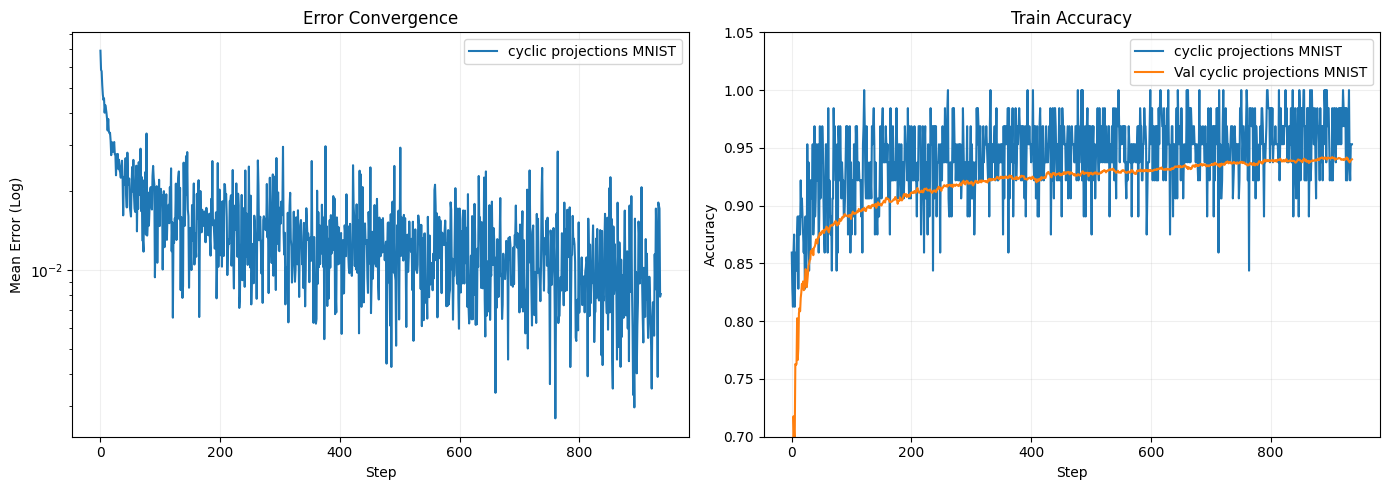

In [5]:
%matplotlib inline
### Visualize Results
df_pure = pd.DataFrame(results.copy())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_pure, x="Step", y="Error", label='cyclic projections MNIST', ax=ax1)
ax1.set_yscale('log'); ax1.set_title("Error Convergence"); ax1.set_ylabel("Mean Error (Log)"); ax1.grid(True, alpha=0.2)
sns.lineplot(data=df_pure, x="Step", y="TrainAcc", label='cyclic projections MNIST', ax=ax2)
sns.lineplot(data=df_pure, x="Step", y="ValAcc", label='Val cyclic projections MNIST', ax=ax2)
ax2.set_ylim(0.7, 1.05); ax2.set_title("Train Accuracy"); ax2.set_ylabel("Accuracy"); ax2.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig('mnist_cyclic_pure.png', dpi=150)

## Nonlinear relaxed projection (weights)

In [6]:
import optax

optim_W0 = optax.adam(learning_rate=0.001)
optim_W1 = optax.adam(learning_rate=0.001)

In [7]:
### Run Nonlinear Relaxed Projections (weights only)
train_loader, test_loader = load_mnist(BATCH_SIZE)
results = []
key = rand_key
key, k1, k2 = random.split(key, 3)
W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01
optim_state_W0 = optim_W0.init(W0)
optim_state_W1 = optim_W1.init(W1)

global_step = 0
test_iter = iter(test_loader)
for epoch in range(NUM_EPOCHS):
    epoch_errors = []
    for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_in, y_target = prepare_batch(x_np, y_np)
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)

        for bp in range(BACKWARDS_PASSES):
            x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)
            h_hidden, w1_proj, x_out = projections.matmul_proj(h_hidden, W1, x_out)
            pseudo_grads_W1 = W1 - w1_proj
            updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
            W1 = optax.apply_updates(W1, updates_W1)

            x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
            x_in, w0_proj, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
            pseudo_grads_W0 = W0 - w0_proj
            updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
            W0 = optax.apply_updates(W0, updates_W0)

        batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
        current_error = float(jnp.mean(batchError))
        train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))

        val_acc = compute_accuracy(W0, W1, test_loader)
        epoch_errors.append(current_error)
        results.append({"Epoch": epoch, "Step": global_step, "Error": current_error, "TrainAcc": train_acc, "Val Acc": val_acc})
        global_step += 1

    val_acc = compute_accuracy(W0, W1, test_loader)
    print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Val Acc: {val_acc:.4f}")
print(f"Final Test Accuracy: {compute_accuracy(W0, W1, test_loader):.4f}")

Epoch 1/1:   0%|          | 0/937 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
%matplotlib inline

### Visualize Results
df_non_linear_weights = pd.DataFrame(results.copy())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_non_linear_weights, x="Step", y="Error", label='non linear weights MNIST', ax=ax1)
ax1.set_yscale('log'); ax1.set_title("Error Convergence"); ax1.set_ylabel("Mean Error (Log)"); ax1.grid(True, alpha=0.2)
sns.lineplot(data=df_non_linear_weights, x="Step", y="TrainAcc", label='non linear weights MNIST', ax=ax2)
sns.lineplot(data=df_non_linear_weights, x="Step", y="ValAcc", label='Val non linear weights MNIST', ax=ax2)
ax2.set_ylim(0, 1.05); ax2.set_title("Train Accuracy"); ax2.set_ylabel("Accuracy"); ax2.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig('mnist_cyclic_relaxed_weights.png', dpi=150)

## Nonlinear relaxed projection (full)

In [3]:
import optax

optim_W0 = optax.adam(learning_rate=0.001)
optim_W1 = optax.adam(learning_rate=0.001)
optim_h_hidden = optax.adam(learning_rate=0.001)
optim_x_hidden = optax.adam(learning_rate=0.001)

In [1]:
### Run Nonlinear Relaxed Projections (full)
train_loader, test_loader = load_mnist(BATCH_SIZE)
results = []
key = rand_key
key, k1, k2 = random.split(key, 3)
W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01
optim_state_W0 = optim_W0.init(W0)
optim_state_W1 = optim_W1.init(W1)

global_step = 0
test_iter = iter(test_loader)
for epoch in range(NUM_EPOCHS):
    epoch_errors = []
    for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        x_in, y_target = prepare_batch(x_np, y_np)
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)
        optim_state_x_hidden = optim_x_hidden.init(x_hidden)
        optim_state_h_hidden = optim_h_hidden.init(h_hidden)

        for bp in range(BACKWARDS_PASSES):
            x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)

            h_hidden_proj, w1_proj, x_out = projections.matmul_proj(h_hidden, W1, x_out)
            pseudo_grads_W1 = W1 - w1_proj
            updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
            W1 = optax.apply_updates(W1, updates_W1)
            pseudo_grads_h = h_hidden - h_hidden_proj
            updates_h, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h, optim_state_h_hidden, h_hidden)
            h_hidden = optax.apply_updates(h_hidden, updates_h)

            x_hidden_proj, _, h_hidden_proj = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
            pseudo_grads_h = h_hidden - h_hidden_proj
            updates_h, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h, optim_state_h_hidden, h_hidden)
            h_hidden = optax.apply_updates(h_hidden, updates_h)
            pseudo_grads_x = x_hidden - x_hidden_proj
            updates_x, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x, optim_state_x_hidden, x_hidden)
            x_hidden = optax.apply_updates(x_hidden, updates_x)

            x_in, w0_proj, x_hidden_proj = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
            pseudo_grads_W0 = W0 - w0_proj
            updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
            W0 = optax.apply_updates(W0, updates_W0)
            pseudo_grads_x = x_hidden - x_hidden_proj
            updates_x, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x, optim_state_x_hidden, x_hidden)
            x_hidden = optax.apply_updates(x_hidden, updates_x)

        batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
        current_error = float(jnp.mean(batchError))
        train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))

        val_acc = compute_accuracy(W0, W1, test_loader)
        epoch_errors.append(current_error)
        results.append({"Epoch": epoch, "Step": global_step, "Error": current_error, "TrainAcc": train_acc, "ValAcc": val_acc})
        global_step += 1

    test_acc = compute_accuracy(W0, W1, test_loader)
    print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Test Acc: {test_acc:.4f}")
print(f"Final Test Accuracy: {compute_accuracy(W0, W1, test_loader):.4f}")

NameError: name 'load_mnist' is not defined

In [2]:
### Visualize Results
df_non_linear_full = pd.DataFrame(results.copy())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_non_linear_full, x="Step", y="Error", label='non linear full MNIST', ax=ax1)
ax1.set_yscale('log'); ax1.set_title("Error Convergence"); ax1.set_ylabel("Mean Error (Log)"); ax1.grid(True, alpha=0.2)
sns.lineplot(data=df_non_linear_full, x="Step", y="TrainAcc", label='non linear full MNIST', ax=ax2)
sns.lineplot(data=df_non_linear_full, x="Step", y="ValAcc", label='Val non linear full MNIST', ax=ax2)
ax2.set_ylim(0, 1.05); ax2.set_title("Train Accuracy"); ax2.set_ylabel("Accuracy"); ax2.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig('mnist_cyclic_relaxed_full.png', dpi=150)

NameError: name 'pd' is not defined

## Compare all 3 approaches

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

if 'df_pure' in locals():
    sns.lineplot(data=df_pure, x="Step", y="TrainAcc", label='Cyclic', ax=ax1)
    sns.lineplot(data=df_pure, x="Step", y="ValAcc", label='Cyclic', ax=ax2)
if 'df_non_linear_weights' in locals():
    sns.lineplot(data=df_non_linear_weights, x="Step", y="TrainAcc", label='Relaxed Weights', ax=ax1)
    sns.lineplot(data=df_non_linear_weights, x="Step", y="ValAcc", label='Relaxed Weights', ax=ax2)
if 'df_non_linear_full' in locals():
    sns.lineplot(data=df_non_linear_full, x="Step", y="TrainAcc", label='Relaxed Full', ax=ax1)
    sns.lineplot(data=df_non_linear_full, x="Step", y="ValAcc", label='Relaxed Full', ax=ax2)

ax1.set_title("Training Accuracy Comparison")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.2)

ax2.set_title("Validation Accuracy Comparison")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.95, 1.05)
ax2.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig('mnist_cyclic_comparison.png', dpi=150)

# Weird initializers

In [8]:
import jax.numpy as jnp
import jax.random as random

def _semi_orthogonal(key, shape):
    """Semi-orthogonal via QR. For (m, n) with m <= n, rows are orthonormal."""
    rows, cols = shape
    n = max(rows, cols)
    A = random.normal(key, (n, n))
    Q, R = jnp.linalg.qr(A)
    Q = Q * jnp.sign(jnp.diag(R))[None, :]   # Haar-uniform sign fix
    return Q[:rows, :cols]

def init_status_quo(key):
    """Original notebook init: std = 0.01 (much smaller than He/Xavier)."""
    k0, k1 = random.split(key, 2)
    W0 = random.normal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
    W1 = random.normal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * 0.01
    return W0, W1

def init_he(key):
    """He normal: var = 2/fan_in. The standard PyTorch default for ReLU."""
    k0, k1 = random.split(key, 2)
    W0 = random.normal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * jnp.sqrt(2.0 / IN_FEATURES)
    W1 = random.normal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * jnp.sqrt(2.0 / HIDDEN_WIDTH)
    return W0, W1

def init_xavier(key):
    """Glorot normal: var = 1/fan_in."""
    k0, k1 = random.split(key, 2)
    W0 = random.normal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * jnp.sqrt(1.0 / IN_FEATURES)
    W1 = random.normal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * jnp.sqrt(1.0 / HIDDEN_WIDTH)
    return W0, W1

def init_orthogonal_he(key):
    """Semi-orthogonal × √2. All singular values equal to √2 (ReLU gain).
    The argument from the response: minimizes contraction factor in vanishing-target theorem."""
    k0, k1 = random.split(key, 2)
    W0 = _semi_orthogonal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * jnp.sqrt(2.0)
    W1 = _semi_orthogonal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * jnp.sqrt(2.0)
    return W0, W1

def init_elser_uniform(key):
    """Uniform[-c, c] with c chosen so var = 2/fan_in (He-equivalent variance, uniform shape)."""
    k0, k1 = random.split(key, 2)
    c0 = jnp.sqrt(6.0 / IN_FEATURES)
    c1 = jnp.sqrt(6.0 / HIDDEN_WIDTH)
    W0 = random.uniform(k0, (HIDDEN_WIDTH, IN_FEATURES), minval=-c0, maxval=c0)
    W1 = random.uniform(k1, (NUM_CLASSES,  HIDDEN_WIDTH), minval=-c1, maxval=c1)
    return W0, W1

INIT_STRATEGIES = {
    "status_quo (std=0.01)": init_status_quo,
    "He normal":             init_he,
    "Xavier normal":         init_xavier,
    "Orthogonal × √2":       init_orthogonal_he,
    "Elser uniform":         init_elser_uniform,
}

In [ ]:
def run_cyclic_with_init(init_fn, label, num_epochs=NUM_EPOCHS, key=None, batches_per_epoch=None):
    """Cyclic projections with a swappable init. Returns (df, W0, W1).
    Uses the same forward_pass / projection calls as Cell 5."""
    if key is None: key = rand_key
    W0, W1 = init_fn(key)

    train_loader, test_loader = load_mnist(BATCH_SIZE)
    results = []
    global_step = 0
    test_iter = iter(test_loader)

    for epoch in range(num_epochs):
        epoch_errors = []
        for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"[{label}] Ep {epoch+1}/{num_epochs}")):
            if batches_per_epoch is not None and batch_idx >= batches_per_epoch: break
            x_in, y_target = prepare_batch(x_np, y_np)
            batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)

            for bp in range(BACKWARDS_PASSES):
                x_out, _, _    = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)
                h_hidden, W1, x_out    = projections.matmul_proj(h_hidden, W1, x_out)
                x_hidden, _,  h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
                x_in,    W0, x_hidden  = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)

            batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
            current_error = float(jnp.mean(batchError))
            train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))
            try: x_val_np, y_val_np = next(test_iter)
            except StopIteration:
                test_iter = iter(test_loader); x_val_np, y_val_np = next(test_iter)
            x_val_in, y_val_target = prepare_batch(x_val_np, y_val_np)
            _, _, _, x_val_out = forward_pass(W0, W1, x_val_in, y_val_target)
            val_acc = float(jnp.mean(jnp.argmax(x_val_out, axis=0) == jnp.array(y_val_np)))
            epoch_errors.append(current_error)
            results.append({"Init": label, "Epoch": epoch, "Step": global_step,
                            "Error": current_error, "TrainAcc": train_acc, "ValAcc": val_acc})
            global_step += 1
        if epoch_errors:
            print(f"  [{label}] Epoch {epoch+1} — Avg Err: {np.mean(epoch_errors):.4e}")
    return pd.DataFrame(results), W0, W1

In [10]:
# Note: each init_fn is called with the same rand_key, so the underlying Gaussian
# samples are identical across strategies — only the scaling/shape of W differs.
# This makes the comparison maximally fair.
init_dfs = []
for label, init_fn in INIT_STRATEGIES.items():
    df, _, _ = run_cyclic_with_init(init_fn, label, num_epochs=2, batches_per_epoch=200)
    init_dfs.append(df)
df_init_sweep = pd.concat(init_dfs, ignore_index=True)

[status_quo (std=0.01)] Ep 1/2:  21%|██▏       | 200/937 [00:04<00:15, 47.37it/s]


  [status_quo (std=0.01)] Epoch 1 — Avg Err: 2.1217e-02


[status_quo (std=0.01)] Ep 2/2:  21%|██▏       | 200/937 [00:04<00:15, 48.83it/s]


  [status_quo (std=0.01)] Epoch 2 — Avg Err: 1.4142e-02


[He normal] Ep 1/2:  21%|██▏       | 200/937 [00:04<00:16, 44.46it/s]


...

  [Orthogonal × √2] Epoch 2 — Avg Err: 3.1253e-02


[Elser uniform] Ep 1/2:  21%|██▏       | 200/937 [00:04<00:16, 44.59it/s]


  [Elser uniform] Epoch 1 — Avg Err: 5.8221e-02


[Elser uniform] Ep 2/2:  21%|██▏       | 200/937 [00:04<00:18, 40.85it/s]

  [Elser uniform] Epoch 2 — Avg Err: 3.0411e-02


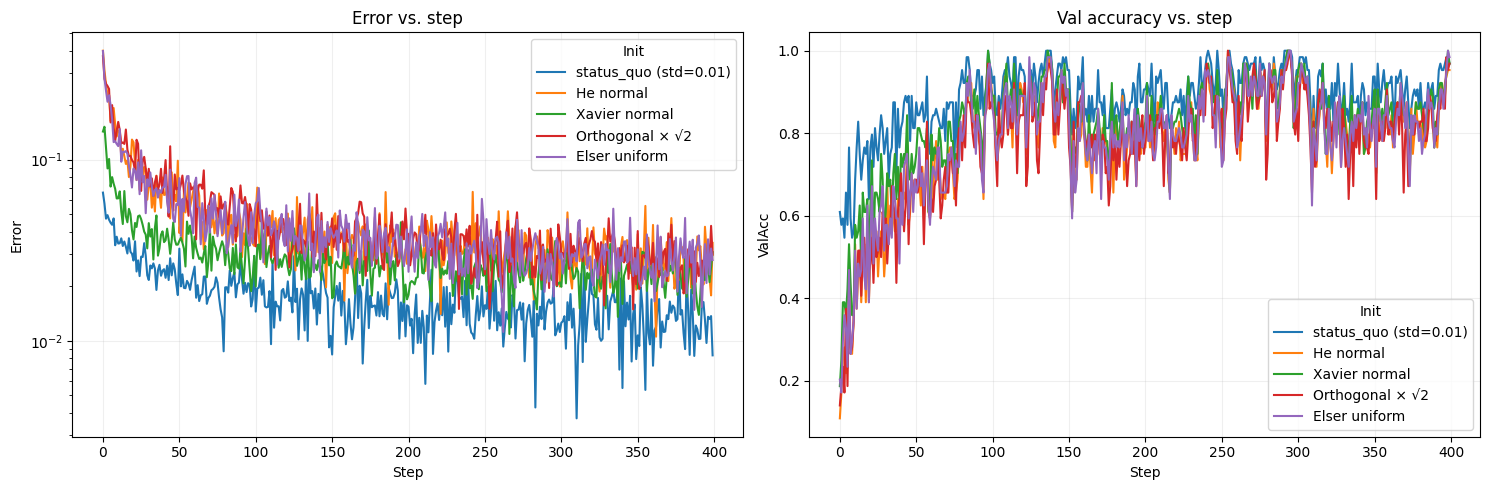

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=df_init_sweep, x="Step", y="Error",   hue="Init", ax=ax1)
ax1.set_yscale('log'); ax1.set_title("Error vs. step"); ax1.grid(True, alpha=0.2)
sns.lineplot(data=df_init_sweep, x="Step", y="ValAcc",  hue="Init", ax=ax2)
ax2.set_title("Val accuracy vs. step"); ax2.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

In [15]:
DEPTH        = 4        # try 4 first, then 8
HIDDEN_DEEP  = 128      # smaller width to keep compute tractable
BACKWARDS_PASSES = 50

def init_he_deep(key, widths):
    keys = random.split(key, len(widths) - 1)
    return [random.normal(k, (widths[i+1], widths[i])) * jnp.sqrt(2.0 / widths[i])
            for i, k in enumerate(keys)]

def init_orth_deep(key, widths):
    keys = random.split(key, len(widths) - 1)
    return [_semi_orthogonal(k, (widths[i+1], widths[i])) * jnp.sqrt(2.0)
            for i, k in enumerate(keys)]

def init_status_quo_deep(key, widths):
    keys = random.split(key, len(widths) - 1)
    return [random.normal(k, (widths[i+1], widths[i])) * 0.01
            for i, k in enumerate(keys)]

INIT_DEEP = {
    "status_quo (std=0.01)": init_status_quo_deep,
    "He normal":             init_he_deep,
    "Orthogonal × √2":       init_orth_deep,
}

def forward_deep(Ws, x_in, y_target):
    pre_acts, post_acts = [], []
    h = x_in
    for W in Ws[:-1]:
        z = W @ h
        pre_acts.append(z)
        h = jnp.where(z > 0, z, 0.1 * z)
        post_acts.append(h)
    x_out = Ws[-1] @ h
    err_pos = jnp.where(y_target == 1, jnp.where(x_out < DELTA, (x_out - DELTA)**2, 0.0), 0.0)
    err_neg = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0.0), 0.0)
    return err_pos + err_neg, pre_acts, post_acts, x_out

def cyclic_step_deep(Ws, pre_acts, post_acts, x_in, x_out, y_target, eye_hidden):
    L = len(Ws)
    x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(NUM_CLASSES), y_target)
    post_acts[-1], Ws[-1], x_out = projections.matmul_proj(post_acts[-1], Ws[-1], x_out)
    for i in range(L - 2, -1, -1):
        pre_acts[i], _, post_acts[i] = leakyReluActivationVectorized(pre_acts[i], eye_hidden, post_acts[i])
        if i == 0:
            x_in, Ws[0], pre_acts[0] = projections.matmul_proj_fixed_X(x_in, Ws[0], pre_acts[0])
        else:
            post_acts[i-1], Ws[i], pre_acts[i] = projections.matmul_proj(post_acts[i-1], Ws[i], pre_acts[i])
    return Ws, pre_acts, post_acts, x_in, x_out

def run_deep(init_fn, label, depth=DEPTH, hidden=HIDDEN_DEEP,
             num_epochs=2, batches_per_epoch=200, key=None):
    if key is None: key = rand_key
    widths = [IN_FEATURES] + [hidden] * (depth - 1) + [NUM_CLASSES]
    Ws = init_fn(key, widths)
    eye_hidden = jnp.eye(hidden)

    train_loader, test_loader = load_mnist(BATCH_SIZE)
    results, global_step = [], 0
    test_iter = iter(test_loader)
    for epoch in range(num_epochs):
        epoch_errors = []
        for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"[{label} L={depth}] Ep {epoch+1}")):
            if batches_per_epoch is not None and batch_idx >= batches_per_epoch: break
            x_in, y_target = prepare_batch(x_np, y_np)
            _, pre_acts, post_acts, x_out = forward_deep(Ws, x_in, y_target)
            for bp in range(BACKWARDS_PASSES):
                Ws, pre_acts, post_acts, x_in, x_out = cyclic_step_deep(
                    Ws, pre_acts, post_acts, x_in, x_out, y_target, eye_hidden)
            err, _, _, x_out_log = forward_deep(Ws, x_in, y_target)
            current_error = float(jnp.mean(err))
            train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))
            try: x_val_np, y_val_np = next(test_iter)
            except StopIteration:
                test_iter = iter(test_loader); x_val_np, y_val_np = next(test_iter)
            x_val_in, y_val_target = prepare_batch(x_val_np, y_val_np)
            _, _, _, x_val_out = forward_deep(Ws, x_val_in, y_val_target)
            val_acc = float(jnp.mean(jnp.argmax(x_val_out, axis=0) == jnp.array(y_val_np)))
            epoch_errors.append(current_error)
            results.append({"Init": label, "Depth": depth, "Epoch": epoch, "Step": global_step,
                            "Error": current_error, "TrainAcc": train_acc, "ValAcc": val_acc})
            global_step += 1
        if epoch_errors:
            print(f"  [{label} L={depth}] Epoch {epoch+1} — Avg Err: {np.mean(epoch_errors):.4e}")
    return pd.DataFrame(results)

[status_quo (std=0.01) L=2] Ep 1:   0%|          | 1/937 [00:00<03:23,  4.60it/s]

[status_quo (std=0.01) L=2] Ep 1:  21%|██▏       | 200/937 [00:21<01:20,  9.20it/s]


  [status_quo (std=0.01) L=2] Epoch 1 — Avg Err: 6.0449e-03


[He normal L=2] Ep 1:  21%|██▏       | 200/937 [00:21<01:20,  9.19it/s]


  [He normal L=2] Epoch 1 — Avg Err: 2.3452e-02


...

  [status_quo (std=0.01) L=8] Epoch 1 — Avg Err: 1.0000e-01


[He normal L=8] Ep 1:  21%|██▏       | 200/937 [00:53<03:16,  3.75it/s]


  [He normal L=8] Epoch 1 — Avg Err: 6.3681e-02


[Orthogonal × √2 L=8] Ep 1:  21%|██▏       | 200/937 [00:55<03:24,  3.60it/s]


  [Orthogonal × √2 L=8] Epoch 1 — Avg Err: 5.1389e-02


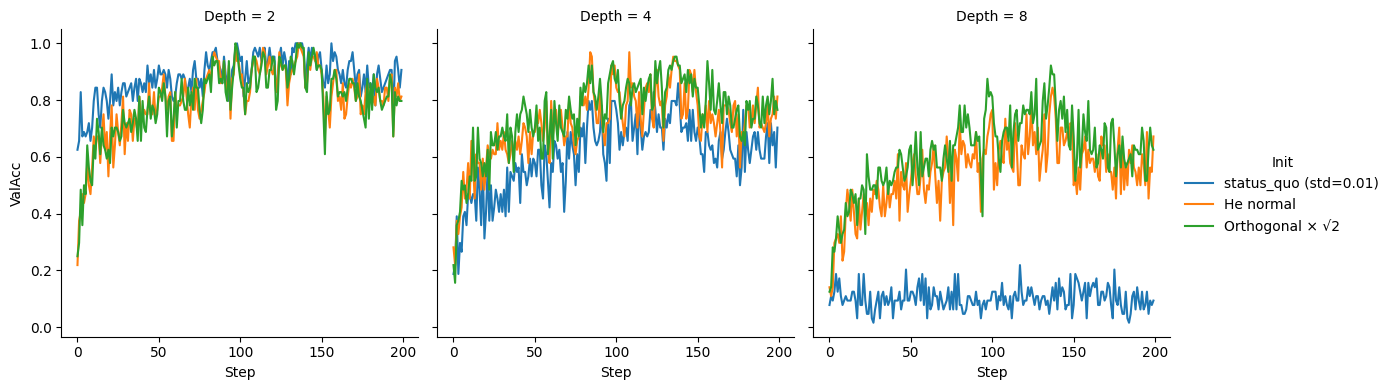

In [16]:
deep_dfs = []
for depth in [2, 4, 8]:                 # 2 = sanity (should match Cell C), 4/8 = the real test
    for label, init_fn in INIT_DEEP.items():
        df = run_deep(init_fn, label, depth=depth, num_epochs=1, batches_per_epoch=200)
        deep_dfs.append(df)
df_deep = pd.concat(deep_dfs, ignore_index=True)

g = sns.relplot(data=df_deep, x="Step", y="ValAcc", hue="Init", col="Depth", kind="line",
                col_wrap=3, height=4, facet_kws={"sharey": True})
g.set_titles("Depth = {col_name}"); plt.show()